# Rice Leaf Disease Classification using SE-SPNet

## Overview
This notebook implements the proposed SE-SPNet architecture for automated rice leaf disease classification using deep learning.

## Objectives
- Develop an efficient CNN-based classification framework
- Improve feature representation using attention mechanisms
- Achieve high classification accuracy with lightweight computation

## Dataset Classes
- Bacterial Blight
- Blast
- Brown Spot

## Framework
- TensorFlow / Keras
- OpenCV
- NumPy
- Scikit-learn

## Author
Dr. Parag Bhuyan

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
    #    print(os.path.join(dirname, filename))

In [2]:
# IMPORT LIBRARIES

import os
import warnings
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

2026-05-27 09:10:24.390328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779873024.416283    1398 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779873024.427247    1398 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779873024.455715    1398 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779873024.455745    1398 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779873024.455749    1398 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


# DATASET CONFIGURATION

In [3]:
DATASET_PATH = "/kaggle/input/datasets/paragbhuyan/rice-leaf-parag/Rice Leaf Dataset"

IMG_SIZE = 128
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 30

CLASS_NAMES = [
    "Bacterialblight",
    "Blast",
    "Brownspot"
]

print("Dataset Path:", DATASET_PATH)

Dataset Path: /kaggle/input/datasets/paragbhuyan/rice-leaf-parag/Rice Leaf Dataset


# DATA LOADING

In [4]:
images = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        labels.append(label)

images = np.array(images, dtype="float32") / 255.0
labels = np.array(labels)

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Images Shape: (4624, 128, 128, 3)
Labels Shape: (4624,)


# SAMPLE VISUALIZATION

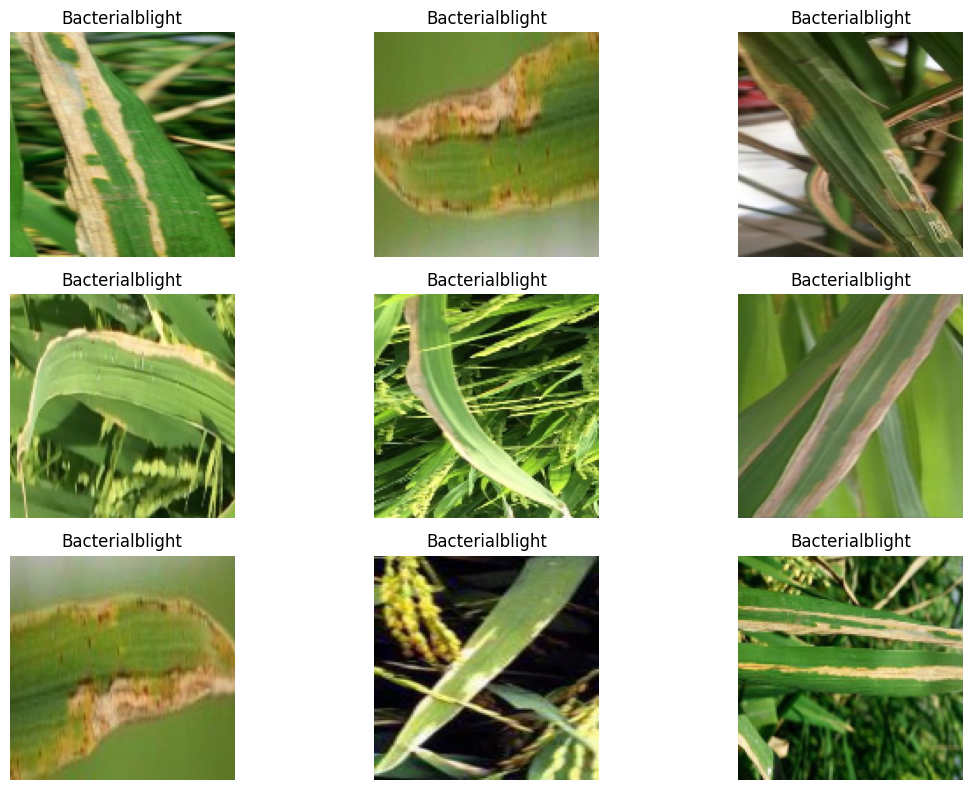

In [5]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])
    plt.title(CLASS_NAMES[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

# TRAIN TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (3699, 128, 128, 3)
Test Shape: (925, 128, 128, 3)


# DATA AUGMENTATION

In [7]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

# SE_SPNET Model

In [8]:
from tensorflow.keras.layers import Input, Conv2D, Concatenate,Reshape,GlobalAvgPool2D,multiply
from tensorflow.keras.layers import GlobalAveragePooling2D as GAP
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Conv2DTranspose, UpSampling2D, ReLU
from tensorflow.keras.layers import *
from tensorflow.keras.layers import GlobalAveragePooling2D as GAP
from tensorflow.keras import layers
from tensorflow.keras.layers import AveragePooling2D,MaxPooling2D
from keras import backend as K
from tensorflow.keras.layers import concatenate
IMG_HEIGHT=128
IMG_WIDTH =128
IMG_CHANNELS = 3
inp = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

def squeeze_block(tensor, ratio=16):
    init = tensor
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    filter_num = init.shape[channel_axis]
    squeeze_shape = (1, 1, filter_num)
    squeeze = GlobalAvgPool2D()(tensor)
    squeeze = Reshape(squeeze_shape)(squeeze)
    squeeze = Dense(filter_num // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(squeeze)
    squeeze = Dense(filter_num, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(squeeze)
    if K.image_data_format() == 'channels_first':
        squeeze = Permute((3, 1, 2))(squeeze)
    x = Multiply()([tensor, squeeze])
    return x

def add_common_layers(y):
            y = layers.BatchNormalization()(y)
            y = layers.LeakyReLU()(y)

            return y
x0 = Conv2D(
   filters = 64, 
   kernel_size=(7, 7), 
   strides=(2, 2),
   padding='same',name='stem_conv')(inp)
x0 = add_common_layers(x0)
conv2d_1 = Conv2D(
        filters = 32,
        kernel_size = (1, 1),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_1_conv1')(x0)
conv2d_2 = Conv2D(
        filters = 64,
        kernel_size = (2, 2),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_1_conv2')(x0)
conv2d_3 = Conv2D(
        filters = 128,
        kernel_size = (3, 3),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_1_conv3')(x0)
conv2d_4 = Conv2D(
        filters = 256,
        kernel_size = (5, 5),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_1_conv4')(x0)
out = Concatenate(name='feature_block_1')([conv2d_1, conv2d_2, conv2d_3, conv2d_4])
#out = BAM(out)
# # # Transition layers for Height, Width and Depth reductions
x = Conv2D(128, (1,1), padding='same', activation='relu', name='transition_conv_1')(out)
x = add_common_layers(x)
x = MaxPooling2D((2,2), strides=(2,2), padding='valid', name='transition_pool_1')(x)
x = squeeze_block(x, 16)
conv2d_5 = Conv2D(
        filters = 32,
        kernel_size = (1, 1),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_2_conv1')(x)
conv2d_6 = Conv2D(
        filters = 64,
        kernel_size = (2, 2),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_2_conv2')(x)
conv2d_7 = Conv2D(
        filters = 128,
        kernel_size = (3, 3),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_2_conv3')(x)
conv2d_8 = Conv2D(
        filters = 256,
        kernel_size = (5, 5),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_2_conv4')(x)
out1 = Concatenate(name='feature_block_2')([conv2d_5, conv2d_6, conv2d_7, conv2d_8])
#out = BAM(out1)
# # # Transition layers for Height, Width and Depth reductions
x = Conv2D(128, (1,1), padding='same', activation='relu', name='transition_conv_2')(out1)
x = add_common_layers(x)
x = MaxPooling2D((2,2), strides=(2,2), padding='valid', name='transition_pool_2')(x)
x = squeeze_block(x, 16)
conv2d_9 = Conv2D(
        filters = 32,
        kernel_size = (1, 1),
        strides =(1, 1),
       padding = 'SAME',
        activation = 'relu', name='feature_block_3_conv1')(x)
conv2d_10 = Conv2D(
        filters = 64,
        kernel_size = (2, 2),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_3_conv2')(x)
conv2d_11 = Conv2D(
        filters = 128,
        kernel_size = (3, 3),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_3_conv3')(x)
conv2d_12 = Conv2D(
        filters = 256,
        kernel_size = (5, 5),
        strides =(1, 1),
        padding = 'SAME',
        activation = 'relu', name='feature_block_3_conv4')(x)
out2 = Concatenate(name='feature_block_3')([conv2d_9, conv2d_10, conv2d_11, conv2d_12])
#out = BAM(out2)
# # # Transition layers for Height, Width and Depth reductions
x = Conv2D(128, (1,1), padding='same', activation='relu',  name='final_transition_conv')(out2)
x = add_common_layers(x)
x = MaxPooling2D((2,2), strides=(2,2), padding='valid', name='final_pool')(x)
x = squeeze_block(x, 16)
x = Flatten(name='flatten_layer')(x)
binary_branch = Dense(32, activation='relu',  name='dense_feature')(x)
binary_branch = Dropout(0.3, name='dropout_layer')(binary_branch)
binary_branch = Dense(3, activation='softmax', name='binary_output')(binary_branch)
model = tf.keras.models.Model(inputs=inp, outputs=[binary_branch])

I0000 00:00:1779873049.870634    1398 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779873049.875747    1398 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# MODEL SUMMARY

In [9]:
model.summary()

plot_model(
    model,
    to_file="model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

print("Model architecture saved.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_1_co… │ (None, 64, 64,    │      2,080 │ leaky_re_lu[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_1_co… │ (None, 64, 64,    │     16,448 │ leaky_re_lu[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_1_co… │ (None, 64, 64,    │     73,856 │ leaky_re_lu[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_1_co… │ (None, 64, 64,    │    409,856 │ leaky_re_lu[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_1     │ (None, 64, 64,    │          0 │ feature_block_1_… │
│ (Concatenate)       │ 480)              │            │ feature_block_1_… │
│                     │                   │            │ feature_block_1_… │
│                     │                   │            │ feature_block_1_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transition_conv_1   │ (None, 64, 64,    │     61,568 │ feature_block_1[… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ transition_conv_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transition_pool_1   │ (None, 32, 32,    │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ transition_pool_… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 128) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 8)   │      1,024 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 128) │      1,024 │ dense[0][0]     

 Total params: 2,974,627 (11.35 MB)

 Trainable params: 2,973,731 (11.34 MB)

 Non-trainable params: 896 (3.50 KB)

Model architecture saved.


# MODEL COMPILATION

In [10]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# MODEL TRAINING

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


I0000 00:00:1779873062.486029    1465 service.cc:152] XLA service 0x786274003630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779873062.486074    1465 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779873062.486083    1465 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779873063.797834    1465 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-27 09:11:14.460107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 09:11:14.617042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 09:11:15.247652: E external/local_xl

  1/116 ━━━━━━━━━━━━━━━━━━━━ 1:02:09 32s/step - accuracy: 0.4062 - loss: 1.3031

I0000 00:00:1779873088.096056    1465 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 34/116 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.5679 - loss: 1.0488

2026-05-27 09:11:40.525794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 09:11:40.678115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 09:11:41.137510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 09:11:41.309948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 09:11:42.692753: E external/local_xla/xla/stream_

116/116 ━━━━━━━━━━━━━━━━━━━━ 82s 429ms/step - accuracy: 0.6524 - loss: 0.8231 - val_accuracy: 0.3459 - val_loss: 3.2439
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step - accuracy: 0.7935 - loss: 0.4902 - val_accuracy: 0.3849 - val_loss: 2.8769
Epoch 3/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.8552 - loss: 0.3926 - val_accuracy: 0.6768 - val_loss: 1.0712
Epoch 4/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.8647 - loss: 0.3520 - val_accuracy: 0.8919 - val_loss: 0.2973
Epoch 5/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.9009 - loss: 0.2735 - val_accuracy: 0.8043 - val_loss: 0.5704
Epoch 6/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.9170 - loss: 0.2296 - val_accuracy: 0.8908 - val_loss: 0.2842
Epoch 7/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.9381 - loss: 0.1940 - val_accuracy: 0.8216 - val_loss: 0.5482
Epoch 8/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.9504 - loss: 0.1368 - val

# ACCURACY & LOSS CURVES

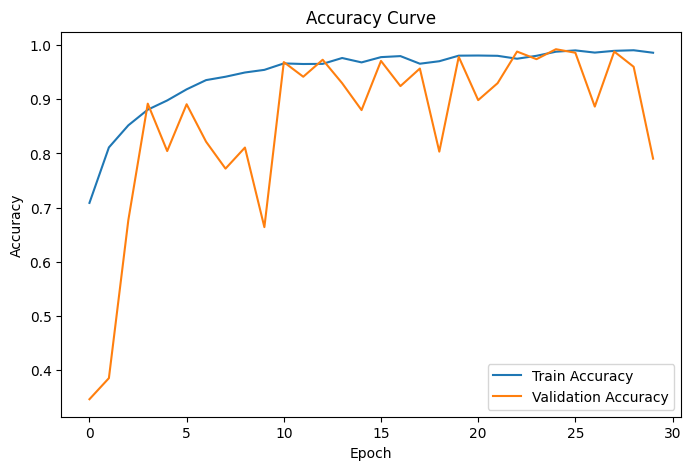

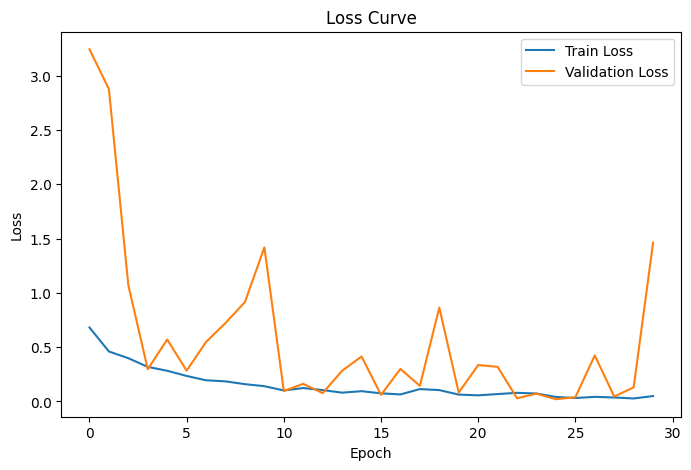

In [12]:
# Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("accuracy_curve.png", dpi=300, bbox_inches='tight')
plt.show()


# Loss Curve
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

# MODEL PREDICTIONS

In [13]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step


# CONFUSION MATRIX

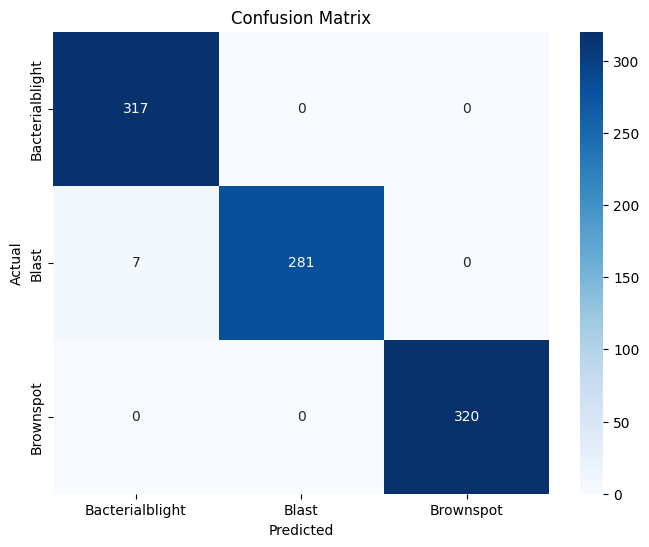

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# CLASSIFICATION REPORT

In [15]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd
import numpy as np

report = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\n========== Classification Report ==========\n")
print(report_df)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("\n========== Overall Metrics ==========\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)

specificities = []

print("\n========== Class-wise Specificity ==========\n")

for i in range(len(CLASS_NAMES)):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)

    specificities.append(specificity)

    print(f"{CLASS_NAMES[i]} Specificity : {specificity:.4f}")

avg_specificity = np.mean(specificities)

print("\n====================================")
print(f"Average Specificity : {avg_specificity:.4f}")
print("====================================")


========== Classification Report ==========

                 precision    recall  f1-score     support
Bacterialblight   0.978395  1.000000  0.989080  317.000000
Blast             1.000000  0.975694  0.987698  288.000000
Brownspot         1.000000  1.000000  1.000000  320.000000
accuracy          0.992432  0.992432  0.992432    0.992432
macro avg         0.992798  0.991898  0.992259  925.000000
weighted avg      0.992596  0.992432  0.992427  925.000000

========== Overall Metrics ==========

Accuracy  : 0.9924
Precision : 0.9926
Recall    : 0.9924
F1-Score  : 0.9924

========== Class-wise Specificity ==========

Bacterialblight Specificity : 0.9885
Blast Specificity : 1.0000
Brownspot Specificity : 1.0000

Average Specificity : 0.9962


# GRAD-CAM VISUALIZATION + OVERLAY


Using Grad-CAM Layer: feature_block_3_conv3

True Class      : Brownspot
Predicted Class : Brownspot
Confidence      : 1.0000


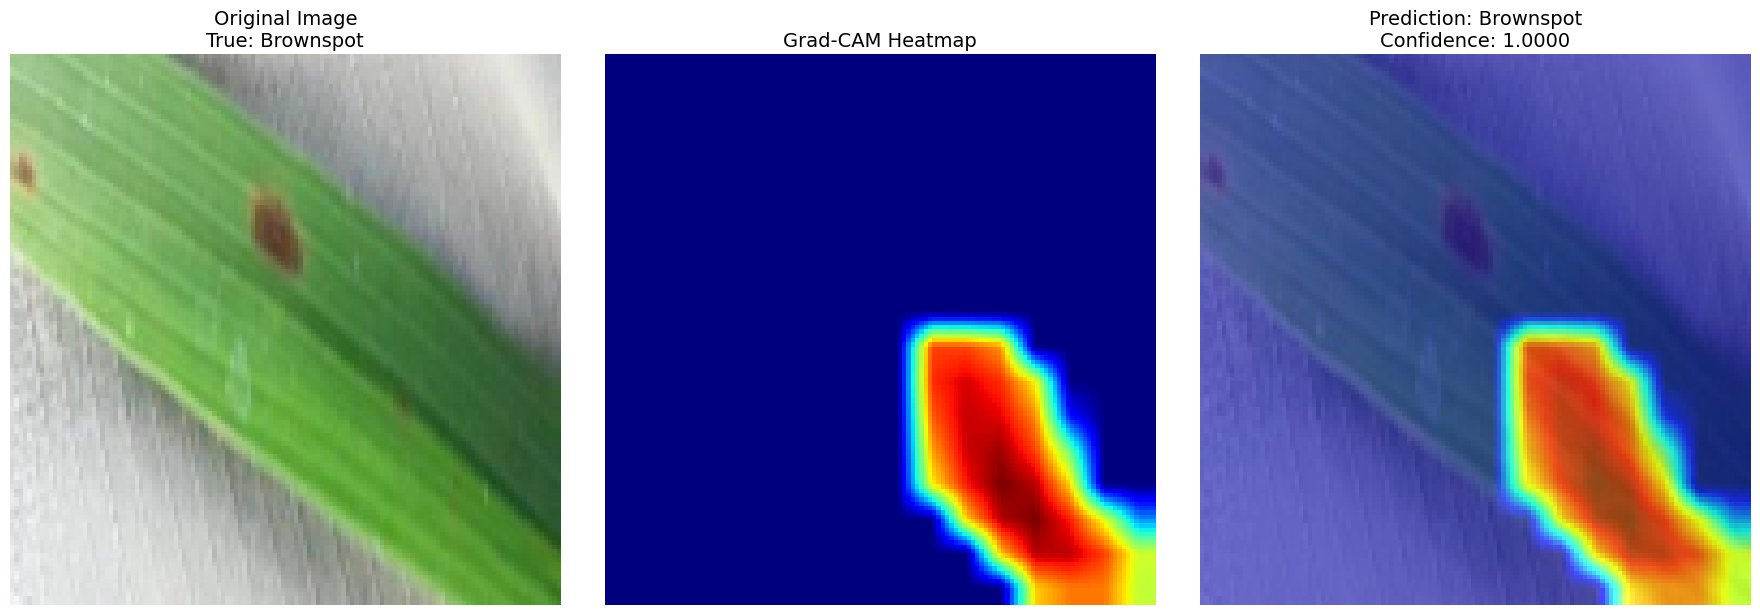


✅ Grad-CAM visualization generated successfully.


In [16]:
last_conv_layer_name = "feature_block_3_conv3"

print(f"\nUsing Grad-CAM Layer: {last_conv_layer_name}")

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)
index = 0
img = X_test[index]
img_array = np.expand_dims(img, axis=0)

prediction = model.predict(
    img_array,
    verbose=0
)

if isinstance(prediction, list):
    prediction = prediction[0]

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

true_class = CLASS_NAMES[y_test[index]]

predicted_label = CLASS_NAMES[predicted_class]

print(f"\nTrue Class      : {true_class}")
print(f"Predicted Class : {predicted_label}")
print(f"Confidence      : {confidence:.4f}")

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    # Handle list outputs
    if isinstance(predictions, list):
        predictions = predictions[0]

    class_channel = predictions[:, predicted_class]

grads = tape.gradient(
    class_channel,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]
conv_outputs = conv_outputs.numpy()
pooled_grads = pooled_grads.numpy()

for i in range(pooled_grads.shape[-1]):

    conv_outputs[:, :, i] *= pooled_grads[i]
heatmap = np.mean(
    conv_outputs,
    axis=-1
)
heatmap = np.maximum(
    heatmap,
    0
)
heatmap = heatmap - np.min(heatmap)
if np.max(heatmap) != 0:
    heatmap = heatmap / np.max(heatmap)
heatmap = np.power(
    heatmap,
    0.4
)
heatmap = cv2.resize(
    heatmap,
    (IMG_WIDTH, IMG_HEIGHT)
)
heatmap_uint8 = np.uint8(
    255 * heatmap
)
colored_heatmap = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)
colored_heatmap = cv2.cvtColor(
    colored_heatmap,
    cv2.COLOR_BGR2RGB
)
original_img = np.uint8(
    img * 255
)
overlay = cv2.addWeighted(
    original_img,
    0.45,
    colored_heatmap,
    0.75,
    0
)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)
axes[0].imshow(original_img)
axes[0].set_title(
    f"Original Image\nTrue: {true_class}",
    fontsize=14
)
axes[0].axis("off")
axes[1].imshow(
    heatmap,
    cmap='jet'
)
axes[1].set_title(
    "Grad-CAM Heatmap",
    fontsize=14
)
axes[1].axis("off")
axes[2].imshow(overlay)
axes[2].set_title(
    f"Prediction: {predicted_label}\nConfidence: {confidence:.4f}",
    fontsize=14
)
axes[2].axis("off")
plt.tight_layout()
plt.savefig(
    "gradcam_visualization.png",
    dpi=300,
    bbox_inches='tight'
)
cv2.imwrite(
    "gradcam_overlay.png",
    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)
plt.show()
print("\n✅ Grad-CAM visualization generated successfully.")

# SAVE MODEL

In [17]:
model.save("trained_SE_SPNet.h5")

print("Model saved successfully.")

Model saved successfully.


# Conclusion

The proposed SE-SPNet architecture achieved strong classification performance for rice leaf disease detection while maintaining computational efficiency.

Key achievements:
- High classification accuracy
- Attention-enhanced feature learning
- Lightweight CNN architecture
- Robust performance across disease categories

Future improvements:
- Real-time deployment
- Mobile optimization
- Grad-CAM interpretability enhancement
- Multi-crop disease classification